# Mutual information score

- scikit-learn's implementation, textbook algorithms and back-of-envelop calculations
- explains why scikit's results do not readily match our estimations

In [1]:
from sklearn import metrics, datasets
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm

## Example 1

In [2]:
# the next 5 lines for y and p are just to produce a cross tabulation containing
# unique values easy for demo purpose
y = [0] * 6
y.extend( [1] * 15)
y.extend( [2] * 24)
p = [0, 1, 1, 2, 2, 2, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 0,
     0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2]
df = pd.DataFrame(list(zip(y, p)), columns=['y', 'p'])
pd.crosstab(df.y, df.p, margins=True)

p,0,1,2,All
y,,,,
0,1,2,3,6
1,4,5,6,15
2,7,8,9,24
All,12,15,18,45


#### Scikit-learn

In [3]:
metrics.mutual_info_score(y, p), metrics.normalized_mutual_info_score(y, p, average_method='arithmetic')

(0.005463676561923342, 0.005316659245237883)

#### Manual back-of-envelop calculation

In [4]:
MI = 1/45*np.log((1/45) / (12/45) / (6/45)) + 2/45*np.log((2/45) / (15/45) / (6/45)) + 3/45*np.log((3/45) / (18/45) / (6/45)) + \
     4/45*np.log((4/45) / (12/45) / (15/45)) + 5/45*np.log((5/45) / (15/45) / (15/45)) + 6/45*np.log((6/45) / (18/45) / (15/45)) + \
     7/45*np.log((7/45) / (12/45) / (24/45)) + 8/45*np.log((8/45) / (15/45) / (24/45)) + 9/45*np.log((9/45) / (18/45) / (24/45))
Hy = -6/45*np.log(6/45) -15/45*np.log(15/45) -24/45*np.log(24/45)
Hp = -12/45*np.log(12/45) -15/45*np.log(15/45) -18/45*np.log(18/45)
NMI = 2*MI/(Hy + Hp)
print(MI, NMI)

0.005463676561923696 0.005316659245238226


#### Putting back-of-envelop calculation into code

In [5]:
# implement algorithm according to
# https://scikit-learn.org/stable/modules/clustering.html
def calcmutualinfo0(df):
    ct = pd.crosstab(df.y, df.p, margins=True).values
    Hy, Hp, MI = 0, 0, 0
    for py in ct[:-1, -1]/ct[-1, -1]:
        Hy += -py * np.log(py)
    for pc in ct[-1, :-1]/ct[-1, -1]:
        Hp += -pc * np.log(pc)
    for col in range(ct.shape[1]-1):
        pc = ct[-1, col]/ct[-1, -1]
        for row in range(ct.shape[0]-1):
            py = ct[row, -1]/ct[-1, -1]
            pij = ct[row, col]/ct[-1, -1]
            if pij != 0:
                MI += pij * np.log(pij/pc/py)
    NMI = 2*MI/(Hy + Hp)
    print(MI, NMI)
calcmutualinfo0(df)

0.005463676561923696 0.005316659245238226


In [6]:
# implement algorithm like
# https://scikit-learn.org/stable/modules/clustering.html
# using log2 instead of log_natural
def calcmutualinfo1(df):
    ct = pd.crosstab(df.y, df.p, margins=True, normalize=True).values
    Hy, Hc, MI = 0, 0, 0
    for py in ct[:-1, -1]/ct[-1, -1]:
        Hy += -py * np.log2(py)
    for pc in ct[-1, :-1]/ct[-1, -1]:
        Hc += -pc * np.log2(pc)
    for col in range(ct.shape[1]-1):
        pc = ct[-1, col]
        for row in range(ct.shape[0]-1):
            py = ct[row, -1]
            pij = ct[row, col]
            if pij != 0:
                MI += pij * np.log2(pij/pc/py)
    NMI = 2*MI/(Hy + Hp)
    print(MI, NMI)
calcmutualinfo1(df)

0.007882419080908577 0.006344586884912296


In [7]:
# implement algorithm according to
# https://course.ccs.neu.edu/cs6140sp15/7_locality_cluster/Assignment-6/NMI.pdf
def calcmutualinfo2(df):
    ct = pd.crosstab(df.y, df.p, margins=True).values
    Hy, Hc, Hyc = 0, 0, 0
    for py in ct[:-1, -1]/ct[-1, -1]:
        Hy += -py * np.log2(py)
    for pc in ct[-1, :-1]/ct[-1, -1]:
        Hc += -pc * np.log2(pc)
    for col in range(ct.shape[1]-1):
        for row in range(ct.shape[0]-1):
            p = ct[row, col]/ct[-1, col]
            if p != 0:
                Hyc += -p * np.log2(p) * ct[-1, col]/ct[-1, -1]
    NMI = 2*MI/(Hy + Hp)
    print(MI, NMI)
calcmutualinfo2(df)

0.005463676561923696 0.004397732511094565


## Example 2

In [8]:
np.random.seed(0)
n_samples = 1000
X, y = datasets.make_circles(n_samples=n_samples, factor=.5, noise=.01)

In [9]:
def plottis(X, y, p):
    plt.set_cmap('Set1')
    plt.scatter(X[:, 0], X[:, 1], c=p, s=3)
    plt.axis('equal');  plt.axis('off')
    plt.title('MI={:.1e}, NMI={:.1e}'.format(metrics.mutual_info_score(y, p), metrics.normalized_mutual_info_score(y, p, average_method='arithmetic')))

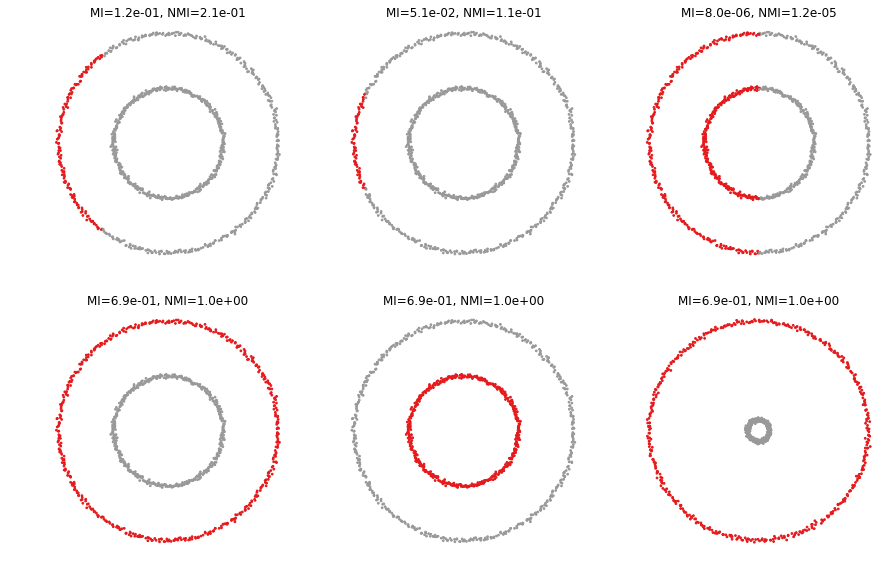

In [10]:
plt.figure(figsize=(15, 15))
plt.subplot(331)
p = np.zeros(len(y))
p[X[:, 0]>-.6] = 1
plottis(X, y, p)

plt.subplot(332)
p = np.zeros(len(y))
p[X[:, 0]>-.9] = 1
plottis(X, y, p)

plt.subplot(333)
p = np.zeros(len(y))
p[X[:, 0]>0] = 1
plottis(X, y, p)

plt.subplot(334)
p = y.copy()
plottis(X, y, p)

plt.subplot(335)
p = np.zeros(len(y))
p[y==0] = 1
plottis(X, y, p)

plt.subplot(336)
X, y = datasets.make_circles(n_samples=n_samples, factor=.1, noise=.01)
p = y.copy()
plottis(X, y, p)

## Example 3

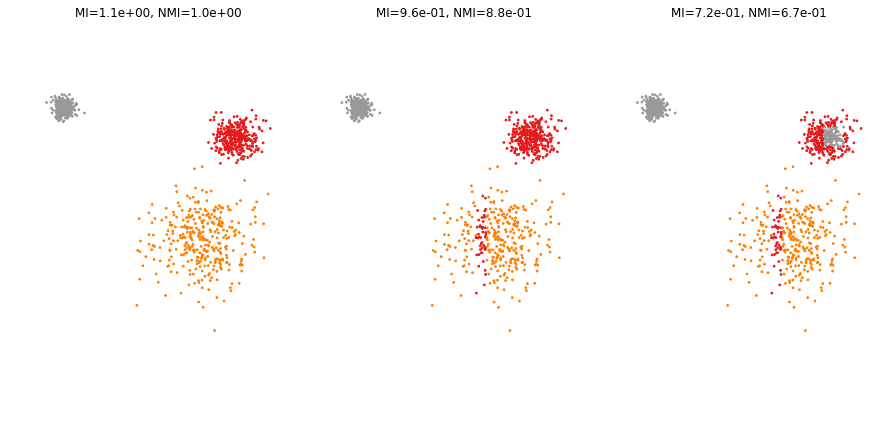

In [11]:
plt.figure(figsize=(15, 7))
plt.subplot(131)
X, y = datasets.make_blobs(n_samples=n_samples, cluster_std=[1, 2.5, .5], random_state=77)
p = y.copy()
plottis(X, y, p)
plt.subplot(132)
p = y.copy()
p[(X[:, 0]>3) & (X[:, 0]<4)] = 0
plottis(X, y, p)
plt.subplot(133)
p = y.copy()
p[(X[:, 0]>3) & (X[:, 0]<4)] = 0
p[(X[:, 0]>8) & (X[:, 0]<10) & (X[:, 1]>2) & (X[:, 1]<4)] = 2
plottis(X, y, p)

## Example 4

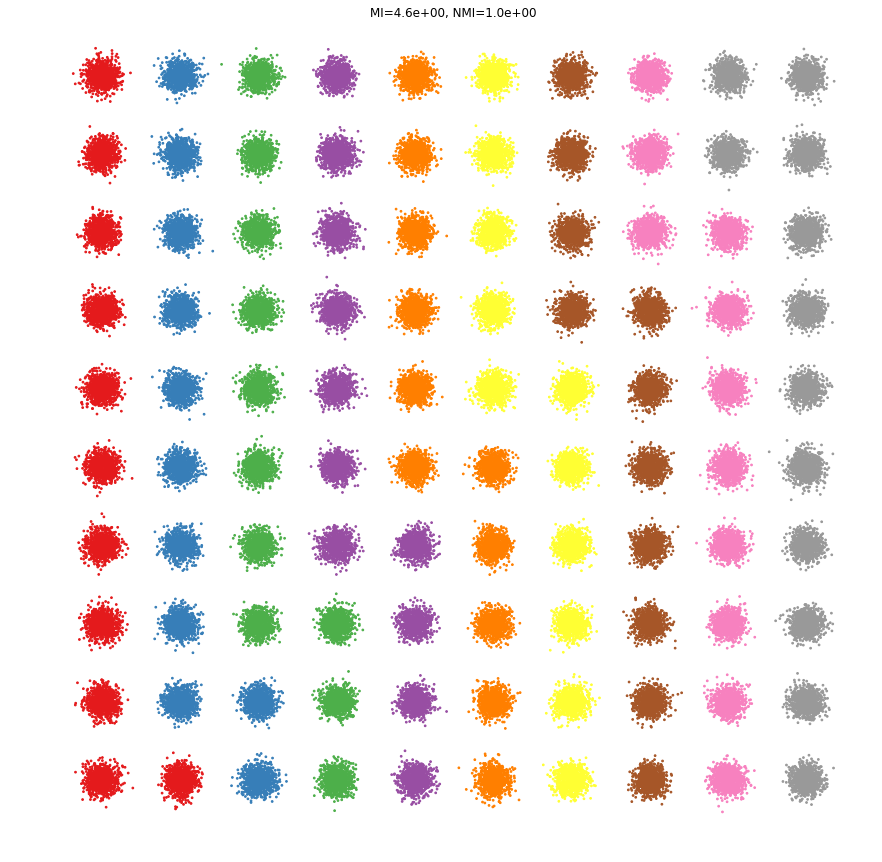

In [12]:
centres = []
for i in np.arange(-50, 50, 10):
    for j in np.arange(-50 ,50, 10):
        centres.append([i, j])
X, y = datasets.make_blobs(n_samples=n_samples*100, centers=centres, random_state=77)
p = y.copy()
plt.figure(figsize=(15, 15))
plottis(X, y, p)

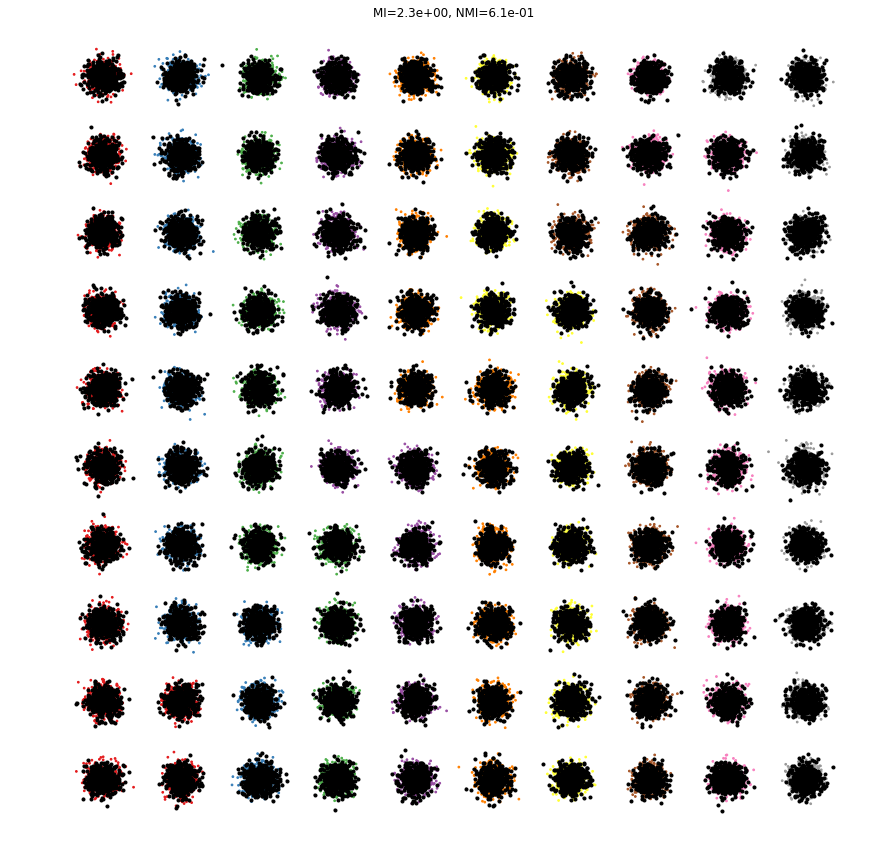

In [13]:
plt.figure(figsize=(15, 15))
p = y.copy()
# create an additional cluster and assign to it half of the points from each of the existing clusters
for i in range(100):
    j = np.where(p==i)[0][:500]
    p[j] = 1 + y.max()
    plt.plot(X[j, 0], X[j, 1], '.k', linewidth=.1)
plottis(X, y, p)